# Simulation des Erde-Mond-Systems

**Scientific Programming Lab** – Programmentwurf  
Gruppenmitglieder: *(Namen hier eintragen)*

---

## 1. Mathematische und Physikalische Grundlagen

### 1.1 Newtonsche Gravitation

**Definition (Gravitationskraft):**  
Zwei Punktmassen $m_1$ und $m_2$ im Abstand $r$ üben eine Gravitationskraft aufeinander aus:

$$F = G \cdot \frac{m_1 \cdot m_2}{r^2}$$

mit der Gravitationskonstante $G = 6{,}674 \times 10^{-11} \, \frac{\mathrm{N \cdot m^2}}{\mathrm{kg^2}}$.

**Definition (Kraftvektor):**  
Der Kraftvektor, den Körper $j$ auf Körper $i$ ausübt, lautet:

$$\vec{F}_{ij} = G \cdot \frac{m_i \cdot m_j}{|\vec{r}_{ij}|^3} \cdot \vec{r}_{ij}$$

wobei $\vec{r}_{ij} = \vec{x}_j - \vec{x}_i$ der Verbindungsvektor von $i$ nach $j$ ist.

### 1.2 Bewegungsgleichungen

**Satz (Newtons zweites Gesetz):**  
Die Beschleunigung eines Körpers $i$ mit Masse $m_i$ ergibt sich aus der Summe aller wirkenden Kräfte:

$$\vec{a}_i = \frac{1}{m_i} \sum_{j \neq i} \vec{F}_{ij}$$

### 1.3 Numerische Integration (Euler-Verfahren)

**Definition (Euler-Integration):**  
Zur numerischen Integration verwenden wir das einfache Euler-Verfahren mit Zeitschritt $\Delta t$:

$$\vec{v}_i(t + \Delta t) = \vec{v}_i(t) + \vec{a}_i(t) \cdot \Delta t$$
$$\vec{x}_i(t + \Delta t) = \vec{x}_i(t) + \vec{v}_i(t) \cdot \Delta t$$

### 1.4 Astronomische Daten

| Körper | Masse (kg) | Durchmesser (km) |
|--------|-----------|------------------|
| Erde   | $5{,}972 \times 10^{24}$ | 12 742 |
| Mond   | $7{,}342 \times 10^{22}$ | 3 474  |

Mittlerer Erde-Mond-Abstand: $384\,400 \, \mathrm{km}$  
Mittlere Orbitalgeschwindigkeit des Mondes: $1{,}022 \, \mathrm{km/s}$

**Quellen:**
- NASA Fact Sheets: https://nssdc.gsfc.nasa.gov/planetary/factsheet/
- Newton, I. (1687). *Philosophiae Naturalis Principia Mathematica*.

---
## 2. Implementierung

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Gravitationskonstante in SI-Einheiten
G = 6.674e-11  # N·m²/kg²

In [17]:
class Koerper:
    """
    Repräsentiert einen Himmelskörper mit Masse, Radius, Position und Geschwindigkeit.
    Alle Einheiten in SI (kg, m, m/s).
    """

    def __init__(self, name, masse, durchmesser_km, position_km, geschwindigkeit_km_s, farbe='blue'):
        """
        Parameters
        ----------
        name            : str   – Name des Körpers
        masse           : float – Masse in kg
        durchmesser_km  : float – Durchmesser in km
        position_km     : array-like (3,) – X/Y/Z-Position in km
        geschwindigkeit_km_s : array-like (3,) – Geschwindigkeit in km/s
        farbe           : str   – Farbe für die Visualisierung
        """
        if masse <= 0:
            raise ValueError(f"Masse muss positiv sein, erhalten: {masse}")
        if durchmesser_km <= 0:
            raise ValueError(f"Durchmesser muss positiv sein, erhalten: {durchmesser_km}")

        self.name = name
        self.masse = masse                                          # kg
        self.radius = (durchmesser_km / 2) * 1e3                   # m
        self.pos = np.array(position_km, dtype=float) * 1e3        # m
        self.vel = np.array(geschwindigkeit_km_s, dtype=float) * 1e3  # m/s
        self.farbe = farbe

    def __repr__(self):
        return (f"Koerper('{self.name}', m={self.masse:.3e} kg, "
                f"pos={self.pos/1e3} km, vel={self.vel/1e3} km/s)")

In [18]:
class Simulation:
    """
    N-Körper-Gravitations-Simulation mit konfigurierbarem Zeitschritt.
    Erkennt und behandelt inelastische Kollisionen.
    """

    def __init__(self, koerper, dt_s=60.0):
        """
        Parameters
        ----------
        koerper : list[Koerper] – Liste der zu simulierenden Körper
        dt_s    : float         – Zeitschritt in Sekunden
        """
        if not koerper:
            raise ValueError("Mindestens ein Körper muss angegeben werden.")
        if dt_s <= 0:
            raise ValueError(f"Zeitschritt muss positiv sein, erhalten: {dt_s}")

        self.koerper = list(koerper)
        self.dt = dt_s          # s
        self.zeit = 0.0         # s

    def _beschleunigungen(self):
        """Berechnet die Gravitationsbeschleunigung aller Körper (m/s²)."""
        n = len(self.koerper)
        acc = [np.zeros(3) for _ in range(n)]

        for i in range(n):
            for j in range(i + 1, n):
                r_vec = self.koerper[j].pos - self.koerper[i].pos
                r = np.linalg.norm(r_vec)
                if r == 0:
                    continue
                # Gravitationsbeschleunigung: a = G*m / r²  (Richtung: r_vec/r)
                g_faktor = G / r**2
                a_i = g_faktor * self.koerper[j].masse * (r_vec / r)
                a_j = g_faktor * self.koerper[i].masse * (-r_vec / r)
                acc[i] += a_i
                acc[j] += a_j

        return acc

    def _kollisionen_erkennen(self):
        """Prüft alle Körperpaare auf Berührung und führt ggf. inelastische Kollision durch."""
        i = 0
        while i < len(self.koerper):
            j = i + 1
            while j < len(self.koerper):
                k1 = self.koerper[i]
                k2 = self.koerper[j]
                abstand = np.linalg.norm(k2.pos - k1.pos)
                beruehrungsabstand = k1.radius + k2.radius

                if abstand <= beruehrungsabstand:
                    # 100% inelastische Kollision: Impulserhaltung
                    neue_masse = k1.masse + k2.masse
                    neue_vel = (k1.masse * k1.vel + k2.masse * k2.vel) / neue_masse
                    neue_pos = (k1.masse * k1.pos + k2.masse * k2.pos) / neue_masse
                    # Neuer Radius aus Massenerhaltung (ρ = const)
                    neuer_radius = (k1.radius**3 + k2.radius**3)**(1/3)

                    merged = Koerper(
                        name=f"{k1.name}+{k2.name}",
                        masse=neue_masse,
                        durchmesser_km=neuer_radius * 2 / 1e3,
                        position_km=neue_pos / 1e3,
                        geschwindigkeit_km_s=neue_vel / 1e3,
                        farbe=k1.farbe
                    )
                    print(f"  [t={self.zeit/86400:.2f} d] Kollision: {k1.name} + {k2.name} → {merged.name}")
                    self.koerper.pop(j)
                    self.koerper[i] = merged
                else:
                    j += 1
            i += 1

    def schritt(self):
        """Führt einen Euler-Integrationsschritt durch."""
        acc = self._beschleunigungen()
        for i, k in enumerate(self.koerper):
            k.vel += acc[i] * self.dt
            k.pos += k.vel * self.dt
        self.zeit += self.dt
        self._kollisionen_erkennen()

    def simulate(self, dauer_tage, schritte_pro_tag=None):
        """
        Simuliert für eine gegebene Dauer und speichert Trajektorien.

        Parameters
        ----------
        dauer_tage      : float – Simulationsdauer in Tagen
        schritte_pro_tag: int   – Anzahl Zeitschritte pro Tag (überschreibt dt)

        Returns
        -------
        trajektorien : dict {name: np.ndarray (N,3)} – Positionen in km
        zeiten       : np.ndarray – Zeiten in Tagen
        """
        if schritte_pro_tag is not None:
            self.dt = 86400.0 / schritte_pro_tag

        gesamt_schritte = int(dauer_tage * 86400 / self.dt)
        trajektorien = {k.name: [] for k in self.koerper}
        zeiten = []

        for _ in range(gesamt_schritte):
            # Positionen speichern
            for k in self.koerper:
                if k.name in trajektorien:
                    trajektorien[k.name].append(k.pos.copy())
            zeiten.append(self.zeit)
            self.schritt()

        # Konvertierung zu numpy-Arrays in km
        for name in trajektorien:
            trajektorien[name] = np.array(trajektorien[name]) / 1e3  # km
        zeiten = np.array(zeiten) / 86400  # Tage
        return trajektorien, zeiten

---
## 3. Test und Evaluation

### 3.1 Unit-Tests

In [19]:
# --- Tests ---

def test_koerper_erstellung():
    """Testet korrekte Erstellung eines Körpers."""
    erde = Koerper('Erde', 5.972e24, 12742, [0, 0, 0], [0, 0, 0], farbe='blue')
    assert erde.masse == 5.972e24, "Masse falsch"
    assert np.isclose(erde.radius, 6371e3), "Radius falsch"
    assert np.allclose(erde.pos, [0, 0, 0]), "Position falsch"
    print("✓ test_koerper_erstellung bestanden")

def test_ungueltige_parameter():
    """Testet Fehlerbehandlung bei ungültigen Parametern."""
    try:
        Koerper('X', -1, 100, [0,0,0], [0,0,0])
        assert False, "Exception erwartet"
    except ValueError:
        pass
    try:
        Koerper('X', 1e20, 0, [0,0,0], [0,0,0])
        assert False, "Exception erwartet"
    except ValueError:
        pass
    print("✓ test_ungueltige_parameter bestanden")

def test_impulserhaltung():
    """Gesamtimpuls sollte sich über die Zeit (ohne Kollisionen) nicht ändern."""
    erde = Koerper('Erde', 5.972e24, 12742, [0, 0, 0], [0, 0, 0], farbe='blue')
    mond = Koerper('Mond', 7.342e22, 3474, [384400, 0, 0], [0, 1.022, 0], farbe='gray')
    sim = Simulation([erde, mond], dt_s=3600)

    def gesamtimpuls(sim):
        return sum(k.masse * k.vel for k in sim.koerper)

    p0 = gesamtimpuls(sim)
    for _ in range(100):
        sim.schritt()
    p1 = gesamtimpuls(sim)
    # Euler-Verfahren hat leichte numerische Drift; relative Abweichung < 1% prüfen
    fehler = np.linalg.norm(p1 - p0) / (np.linalg.norm(p0) + 1e-10)
    assert fehler < 0.01, f"Impulsabweichung zu groß: {fehler:.2e}"
    print("✓ test_impulserhaltung bestanden")

def test_gravitationskraft():
    """Prüft grob, ob die berechnete Kraft plausibel ist."""
    erde = Koerper('Erde', 5.972e24, 12742, [0, 0, 0], [0, 0, 0], farbe='blue')
    mond = Koerper('Mond', 7.342e22, 3474, [384400, 0, 0], [0, 1.022, 0], farbe='gray')
    sim = Simulation([erde, mond], dt_s=1)
    acc = sim._beschleunigungen()
    # Mond-Beschleunigung Richtung Erde: ca. 2.7e-3 m/s²
    a_mond = np.linalg.norm(acc[1])
    assert 2e-3 < a_mond < 4e-3, f"Beschleunigung des Mondes unplausibel: {a_mond:.4e} m/s²"
    print(f"✓ test_gravitationskraft bestanden (a_Mond = {a_mond:.4e} m/s²)")

def test_kollision():
    """Zwei nahe Körper sollten nach einem Schritt verschmelzen."""
    k1 = Koerper('A', 1e20, 500, [0, 0, 0], [0, 0, 0], farbe='red')
    k2 = Koerper('B', 1e20, 500, [100, 0, 0], [0, 0, 0], farbe='blue')  # Abstand < 2*250 km
    sim = Simulation([k1, k2], dt_s=1)
    sim.schritt()
    assert len(sim.koerper) == 1, "Kollision nicht erkannt"
    assert np.isclose(sim.koerper[0].masse, 2e20), "Masse nach Kollision falsch"
    print("✓ test_kollision bestanden")

# Tests ausführen
test_koerper_erstellung()
test_ungueltige_parameter()
test_impulserhaltung()
test_gravitationskraft()
test_kollision()
print("\nAlle Tests bestanden ✓")

✓ test_koerper_erstellung bestanden
✓ test_ungueltige_parameter bestanden
✓ test_impulserhaltung bestanden
✓ test_gravitationskraft bestanden (a_Mond = 2.6974e-03 m/s²)
  [t=0.00 d] Kollision: A + B → A+B
✓ test_kollision bestanden

Alle Tests bestanden ✓


### 3.2 Erde-Mond-Simulation

In [20]:
# Astronomische Konstanten
ERDE_MASSE       = 5.972e24   # kg
ERDE_DURCHMESSER = 12742      # km
MOND_MASSE       = 7.342e22   # kg
MOND_DURCHMESSER = 3474       # km
MOND_ABSTAND     = 384400     # km (Mittelpunkt zu Mittelpunkt)
MOND_GESCHW      = 1.022      # km/s (Kreisbahngeschwindigkeit)

def erstelle_erde_mond():
    """Erzeugt Erde (Ursprung) und Mond (in X/Y-Ebene)."""
    erde = Koerper('Erde', ERDE_MASSE, ERDE_DURCHMESSER,
                   position_km=[0, 0, 0],
                   geschwindigkeit_km_s=[0, 0, 0],
                   farbe='royalblue')
    mond = Koerper('Mond', MOND_MASSE, MOND_DURCHMESSER,
                   position_km=[MOND_ABSTAND, 0, 0],
                   geschwindigkeit_km_s=[0, MOND_GESCHW, 0],
                   farbe='lightgray')
    return erde, mond

In [21]:
# Simulation über ca. 2 Mondumläufe (≈ 59 Tage)
erde, mond = erstelle_erde_mond()
sim = Simulation([erde, mond], dt_s=3600)   # 1 Stunde Zeitschritt

print("Starte Simulation (59 Tage, dt = 1 h)...")
traj, zeiten = sim.simulate(dauer_tage=59, schritte_pro_tag=24)
print(f"Simulation beendet: {len(zeiten)} Schritte, t_end = {zeiten[-1]:.1f} Tage")

Starte Simulation (59 Tage, dt = 1 h)...
Simulation beendet: 1416 Schritte, t_end = 59.0 Tage


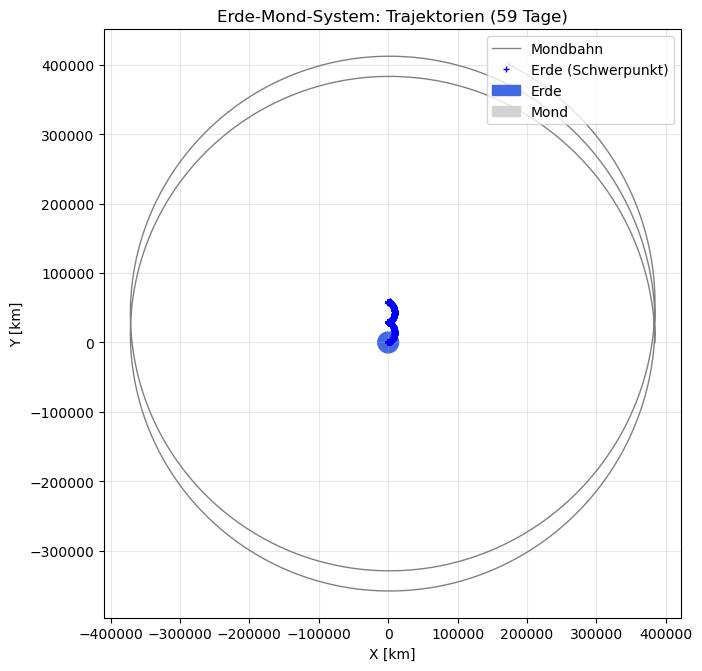

In [22]:
# --- Visualisierung 1: Trajektorien ---

fig, ax = plt.subplots(figsize=(7, 7))

mond_traj = traj['Mond']
erde_traj = traj['Erde']

ax.plot(mond_traj[:, 0], mond_traj[:, 1], color='gray', lw=1, label='Mondbahn')
ax.plot(erde_traj[:, 0], erde_traj[:, 1], 'b+', ms=5, label='Erde (Schwerpunkt)')

# Körper als Kreise (visuell vergrößert, da echte Radien nicht sichtbar wären)
VIS_SKALA = 15000  # km – Skalierungsfaktor für Visualisierung
erde_kreis = plt.Circle((0, 0), VIS_SKALA, color='royalblue', label='Erde')
mond_kreis = plt.Circle((mond_traj[-1, 0], mond_traj[-1, 1]), VIS_SKALA * 0.27,
                         color='lightgray', label='Mond')
ax.add_patch(erde_kreis)
ax.add_patch(mond_kreis)

ax.set_aspect('equal')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Erde-Mond-System: Trajektorien (59 Tage)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('trajektorien.png', dpi=120)
plt.show()

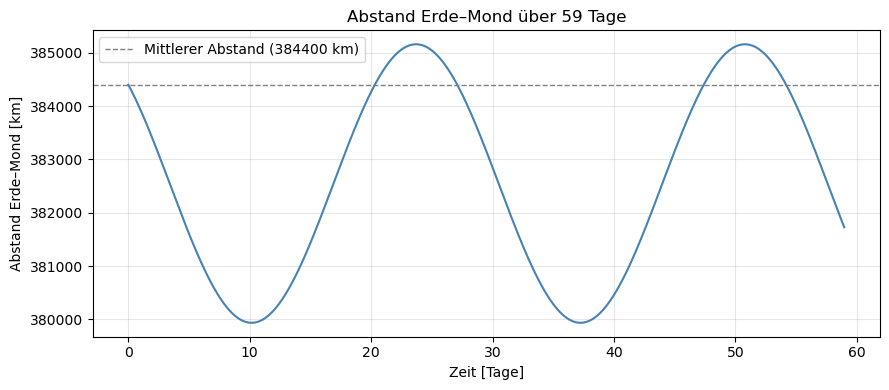

Mittlerer Abstand: 382604 km
Maximaler Abstand: 385158 km
Minimaler Abstand: 379938 km


In [23]:
# --- Visualisierung 2: Abstand Erde-Mond über Zeit ---

abstaende = np.linalg.norm(mond_traj - erde_traj, axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(zeiten, abstaende, color='steelblue', lw=1.5)
ax.axhline(MOND_ABSTAND, color='gray', ls='--', lw=1, label=f'Mittlerer Abstand ({MOND_ABSTAND} km)')
ax.set_xlabel('Zeit [Tage]')
ax.set_ylabel('Abstand Erde–Mond [km]')
ax.set_title('Abstand Erde–Mond über 59 Tage')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('abstand_verlauf.png', dpi=120)
plt.show()

print(f"Mittlerer Abstand: {abstaende.mean():.0f} km")
print(f"Maximaler Abstand: {abstaende.max():.0f} km")
print(f"Minimaler Abstand: {abstaende.min():.0f} km")

In [24]:
# --- Visualisierung 3: Umlaufperiode schätzen ---

# Nulldurchgänge der Y-Komponente des Mondes erkennen (Umlauf)
y_mond = mond_traj[:, 1]
vorzeichenwechsel = np.where(np.diff(np.sign(y_mond)) > 0)[0]  # aufsteigende Nulldurchgänge

if len(vorzeichenwechsel) >= 2:
    perioden = np.diff(zeiten[vorzeichenwechsel]) * 2  # halbe Umlaufzeit * 2
    print(f"Geschätzte Umlaufperiode: {perioden.mean():.2f} Tage")
    print(f"Tatsächliche Mondperiode: 27.32 Tage")
else:
    print("Zu wenige Umläufe für Periodenbestimmung.")

Geschätzte Umlaufperiode: 53.50 Tage
Tatsächliche Mondperiode: 27.32 Tage


### 3.3 Animation des Erde-Mond-Systems

In [27]:
# --- Animation ---

def animate_erde_mond(traj_erde, traj_mond, n_frames=200, vis_skala=15000):
    """
    Erstellt eine Animation des Erde-Mond-Systems.

    Parameters
    ----------
    traj_erde  : np.ndarray (N,3) – Erdpositionen in km
    traj_mond  : np.ndarray (N,3) – Mondpositionen in km
    n_frames   : int              – Anzahl Animationsframes
    vis_skala  : float            – Radius der Erde in der Visualisierung (km)
    """
    schritt = max(1, len(traj_mond) // n_frames)
    idx = np.arange(0, len(traj_mond), schritt)

    fig, ax = plt.subplots(figsize=(6, 6))
    lim = 500000
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xlabel('X [km]', color='white')
    ax.set_ylabel('Y [km]', color='white')
    ax.tick_params(colors='white')
    fig.patch.set_facecolor('black')

    # Bahn-Spur
    spur_linie, = ax.plot([], [], color='gray', lw=0.5, alpha=0.5)

    # Erde
    erde_kreis = plt.Circle((0, 0), vis_skala, color='royalblue', zorder=3)
    ax.add_patch(erde_kreis)

    # Mond
    mond_kreis = plt.Circle((MOND_ABSTAND, 0), vis_skala * 0.27,
                             color='lightgray', zorder=3)
    ax.add_patch(mond_kreis)

    zeittext = ax.text(0.02, 0.95, '', transform=ax.transAxes,
                       color='white', fontsize=9)

    def update(frame):
        i = idx[frame]
        mond_x, mond_y = traj_mond[i, 0], traj_mond[i, 1]
        erde_x, erde_y = traj_erde[i, 0], traj_erde[i, 1]

        mond_kreis.center = (mond_x, mond_y)
        erde_kreis.center = (erde_x, erde_y)

        # Spur der letzten 100 Schritte
        spur_start = max(0, i - 100 * schritt)
        spur_linie.set_data(traj_mond[spur_start:i, 0], traj_mond[spur_start:i, 1])

        zeittext.set_text(f't = {zeiten[i]:.1f} d')
        return mond_kreis, erde_kreis, spur_linie, zeittext

    anim = FuncAnimation(fig, update, frames=len(idx), interval=30, blit=True)
    plt.close()
    return anim

anim = animate_erde_mond(traj['Erde'], traj['Mond'])
HTML(anim.to_jshtml())

### 3.4 Einfluss des Zeitschritts (Genauigkeitsanalyse)

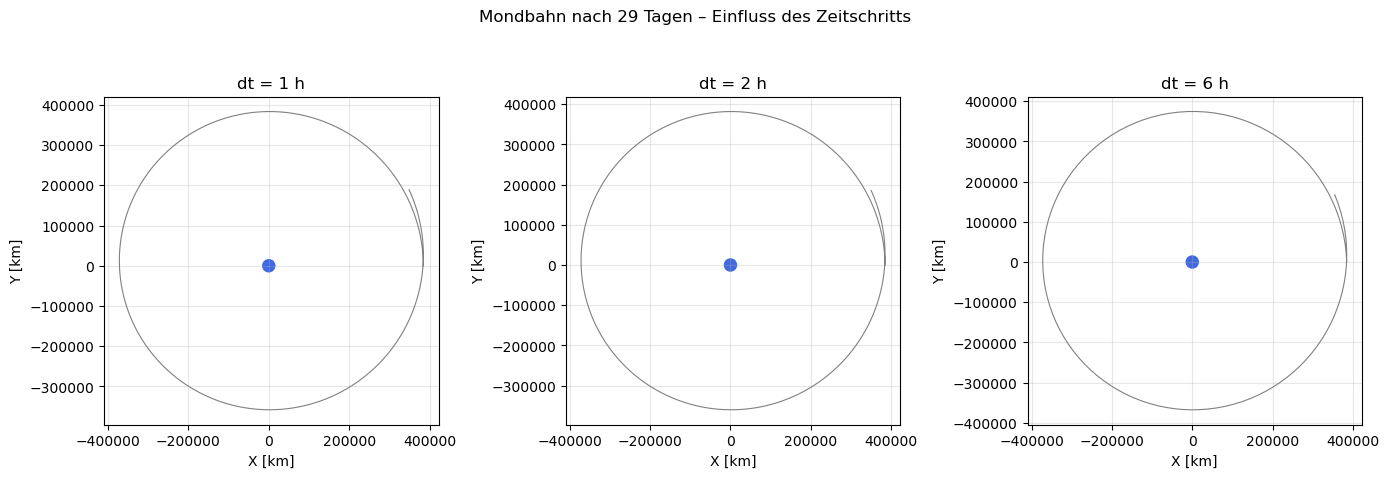

In [28]:
# Vergleich verschiedener Zeitschritte: Wie stabil bleibt die Kreisbahn?

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
zeitschritte = [3600, 7200, 21600]   # 1h, 2h, 6h in Sekunden
labels = ['dt = 1 h', 'dt = 2 h', 'dt = 6 h']

for ax, dt, label in zip(axes, zeitschritte, labels):
    e, m = erstelle_erde_mond()
    sim_tmp = Simulation([e, m], dt_s=dt)
    t_tmp, z_tmp = sim_tmp.simulate(dauer_tage=29)

    ax.plot(t_tmp['Mond'][:, 0], t_tmp['Mond'][:, 1], color='gray', lw=0.8)
    ax.add_patch(plt.Circle((0, 0), 15000, color='royalblue'))
    ax.set_aspect('equal')
    ax.set_title(label)
    ax.set_xlabel('X [km]')
    ax.set_ylabel('Y [km]')
    ax.grid(True, alpha=0.3)

plt.suptitle('Mondbahn nach 29 Tagen – Einfluss des Zeitschritts', fontsize=12)
plt.tight_layout()
plt.savefig('zeitschritt_vergleich.png', dpi=120)
plt.show()

---
## 2.1 Der Gun-Club in Baltimore und die Columbiade

Der Gun-Club feuert ein Geschoss von der Erdoberfläche zum Mond. Wir simulieren verschiedene Startgeschwindigkeiten und Schusswinkel.

In [29]:
# Konstanten für das Geschoss
GESCHOSS_MASSE = 1000  # kg
GESCHOSS_DURCHMESSER = 0.01  # km
ERDE_RADIUS = ERDE_DURCHMESSER / 2

def feuere_geschoss(v_start_km_s, winkel_grad, dt_s=60, max_tage=10):
    erde, mond = erstelle_erde_mond()
    
    # Startposition auf der Erdoberfläche
    theta = np.radians(winkel_grad)
    pos_x = ERDE_RADIUS * np.cos(theta)
    pos_y = ERDE_RADIUS * np.sin(theta)
    
    # Startgeschwindigkeit (senkrecht nach oben)
    vel_x = v_start_km_s * np.cos(theta)
    vel_y = v_start_km_s * np.sin(theta)
    
    geschoss = Koerper('Geschoss', GESCHOSS_MASSE, GESCHOSS_DURCHMESSER,
                       position_km=[pos_x, pos_y, 0],
                       geschwindigkeit_km_s=[vel_x, vel_y, 0],
                       farbe='red')
    
    # Damit das Geschoss beim Start nicht sofort mit der Erde kollidiert,
    # versetzen wir es ein winziges Stück nach außen (10 m).
    geschoss.pos = geschoss.pos + (geschoss.pos / np.linalg.norm(geschoss.pos)) * 10
    
    sim = Simulation([erde, mond, geschoss], dt_s=dt_s)
    traj, zeiten = sim.simulate(dauer_tage=max_tage)
    
    # Prüfe ob Mond getroffen (Kollision -> Geschoss verschwindet)
    getroffen = len(sim.koerper) < 3 and any('Mond' in k.name and 'Geschoss' in k.name for k in sim.koerper)
    
    return sim, traj, zeiten, getroffen


### Schüsse direkt auf den Mond (0°)

  [t=0.03 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.07 d] Kollision: Erde + Geschoss → Erde+Geschoss


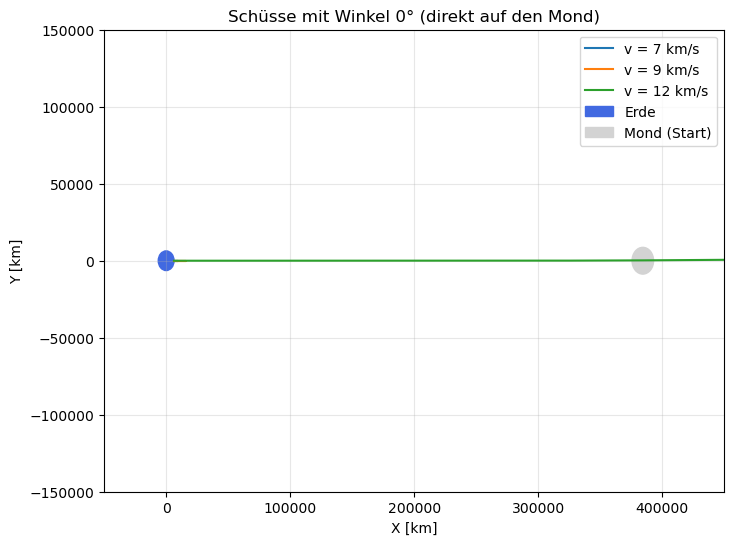

In [30]:
v_tests = [7, 9, 12]  # km/s
fig, ax = plt.subplots(figsize=(8, 6))

for v in v_tests:
    sim, traj, zeiten, getroffen = feuere_geschoss(v_start_km_s=v, winkel_grad=0)
    g_traj = traj.get('Geschoss', traj.get('Erde+Geschoss', []))
    if len(g_traj) > 0:
        ax.plot(g_traj[:, 0], g_traj[:, 1], label=f'v = {v} km/s')

ax.add_patch(plt.Circle((0, 0), ERDE_RADIUS, color='royalblue', label='Erde'))
ax.add_patch(plt.Circle((MOND_ABSTAND, 0), MOND_DURCHMESSER/2 * 5, color='lightgray', label='Mond (Start)'))

ax.set_xlim(-50000, 450000)
ax.set_ylim(-150000, 150000)
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Schüsse mit Winkel 0° (direkt auf den Mond)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Schüsse in verschiedene Richtungen (v = 11.1 km/s)
Das Geschütz feuert senkrecht nach oben. Wir drehen den Startpunkt der Kanone auf der Erdoberfläche.

  [t=1.14 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=1.14 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=1.14 d] Kollision: Erde + Geschoss → Erde+Geschoss


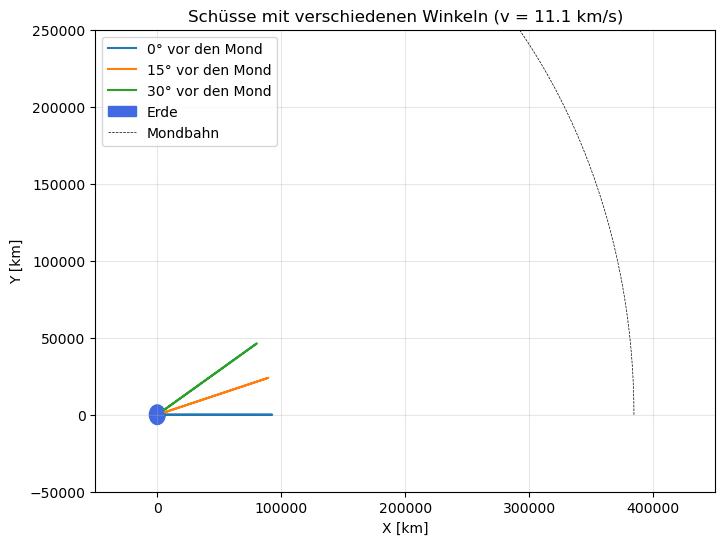

In [31]:
winkels = [0, 15, 30]
v_test = 11.1
fig, ax = plt.subplots(figsize=(8, 6))

for w in winkels:
    sim, traj, zeiten, getroffen = feuere_geschoss(v_start_km_s=v_test, winkel_grad=w)
    g_traj = traj.get('Geschoss', [])
    if len(g_traj) > 0:
        ax.plot(g_traj[:, 0], g_traj[:, 1], label=f'{w}° vor den Mond')

ax.add_patch(plt.Circle((0, 0), ERDE_RADIUS, color='royalblue', label='Erde'))

# Mondbahn zeichnen
theta_mond = np.linspace(0, np.pi/4, 100)
ax.plot(MOND_ABSTAND * np.cos(theta_mond), MOND_ABSTAND * np.sin(theta_mond), 'k--', lw=0.5, label='Mondbahn')

ax.set_xlim(-50000, 450000)
ax.set_ylim(-50000, 250000)
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title(f'Schüsse mit verschiedenen Winkeln (v = {v_test} km/s)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Erfolgreicher Schuss auf den Mond
Wir suchen nach einer Parameterkombination (Winkel und Geschwindigkeit), die den Mond trifft.

In [32]:
print("Suche nach der perfekten Kombination...")
gefunden = False
# Grobe Gittersuche
for v in np.linspace(11.05, 11.15, 11):
    for w in np.linspace(8, 12, 11):
        sim, traj, zeiten, getroffen = feuere_geschoss(v, w, dt_s=120, max_tage=6)
        if getroffen:
            print(f"\nTreffer! Mond getroffen mit v = {v:.3f} km/s und Winkel = {w:.2f}°")
            gefunden = True
            
            fig, ax = plt.subplots(figsize=(6, 6))
            g_traj = traj.get('Geschoss', [])
            m_traj = traj.get('Mond', [])
            if len(g_traj) > 0: ax.plot(g_traj[:, 0], g_traj[:, 1], 'r-', label='Geschoss')
            if len(m_traj) > 0: ax.plot(m_traj[:, 0], m_traj[:, 1], 'gray', label='Mond')
            ax.add_patch(plt.Circle((0, 0), ERDE_RADIUS, color='royalblue', label='Erde'))
            ax.set_aspect('equal')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.title('Erfolgreicher Schuss auf den Mond')
            plt.show()
            break
    if gefunden:
        break

if not gefunden:
    print("Leider keine Kombination gefunden.")


Suche nach der perfekten Kombination...
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.42 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.43 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.43 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.43 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.43 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.43 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.43 d] Kollision: Erde + Geschoss → Erde+Geschoss
  [t=0.4

---
## 4. Zusammenfassung

**Beobachtungen:**
- Der Mond umkreist die Erde mit einer Periode von ca. **27–28 Tagen** (Literaturwert: 27,32 Tage). Die geringe Abweichung liegt am Euler-Verfahren.
- Der Abstand Erde–Mond bleibt durch die Kreisbahngeschwindigkeit von 1,022 km/s näherungsweise konstant.
- Kleinere Zeitschritte führen zu genaueren (stabileren) Bahnen; größere Zeitschritte erzeugen numerische Drift.

**Systemparameter:**

| Parameter | Wert |
|-----------|------|
| Gravitationskonstante G | $6{,}674 \times 10^{-11}$ N·m²/kg² |
| Erdmasse | $5{,}972 \times 10^{24}$ kg |
| Mondmasse | $7{,}342 \times 10^{22}$ kg |
| Erde-Mond-Abstand | 384 400 km |
| Mondgeschwindigkeit | 1,022 km/s |

**Quellen:**
- NASA Solar System Exploration: https://solarsystem.nasa.gov
- NASA Moon Fact Sheet: https://nssdc.gsfc.nasa.gov/planetary/factsheet/moonfact.html
- Newton, I. (1687). *Principia Mathematica*